In [10]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

Currently processing train Catalog,Discover 5193 File...
Currently processing val Catalog,Discover 1671 File...


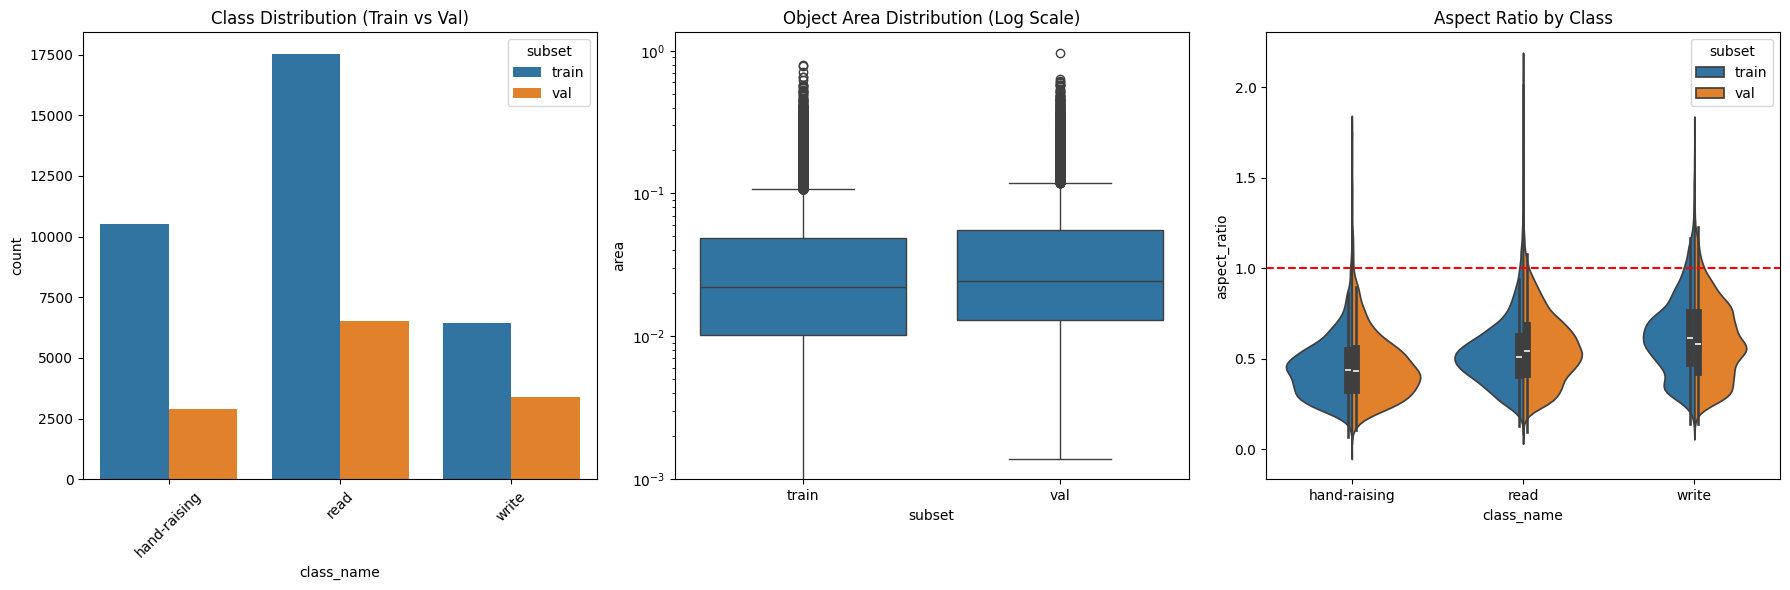

------------------------------
class_name  hand-raising   read  write
subset                                
train              10538  17539   6447
val                 2915   6539   3394
------------------------------

Child group index Report: SCB5-Handrise-Read-write-2024-9-17
class_name   hand-raising   read  write  Row_Sum
subset                                          
train               10538  17539   6447    34524
val                  2915   6539   3394    12848
Total_Annos         13453  24078   9841    47372
--------------------------------------------------
 Dataset Contains (Bounding Boxes): 47372 个
 Category situation:
class_name
read            50.827493
hand-raising    28.398632
write           20.773875
Name: proportion, dtype: float64


In [11]:
SCB5_Handrise_Read_write = "/kaggle/input/datasets/hejuncheung/scb-datasets/SCB5-Handrise-Read-write-2024-9-17/SCB5-Handrise-Read-write-2024-9-17"

def get_full_df(base_path):
    all_data = []
    sub_types = ['train', 'val']
    
    for stype in sub_types:
        label_files = glob.glob(os.path.join(base_path, "labels", stype, "*.txt"))
        print(f"Currently processing {stype} Catalog,Discover {len(label_files)} File...")
        
        for lf in label_files:
            with open(lf, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        all_data.append({
                            'subset': stype,
                            'class_id': int(parts[0]),
                            'width': float(parts[3]),
                            'height': float(parts[4]),
                            'area': float(parts[3]) * float(parts[4])
                        })
    
    if not all_data:
        print("！！！Not a Vaild Path！！！")
        return pd.DataFrame()
    return pd.DataFrame(all_data)

df = get_full_df(SCB5_Handrise_Read_write)

if not df.empty:
    CLASS_MAP = {0: "hand-raising", 1: "read", 2: "write"}
    df['class_name'] = df['class_id'].map(CLASS_MAP).fillna(df['class_id'])

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    sns.countplot(data=df, x='class_name', hue='subset')
    plt.title("Class Distribution (Train vs Val)")
    plt.xticks(rotation=45)

    plt.subplot(1, 3, 2)
    sns.boxplot(data=df, x='subset', y='area')
    plt.yscale('log') 
    plt.title("Object Area Distribution (Log Scale)")

    df['aspect_ratio'] = df['width'] / df['height']
    plt.subplot(1, 3, 3)
    sns.violinplot(data=df, x='class_name', y='aspect_ratio', hue='subset', split=True)
    plt.axhline(1, color='red', linestyle='--')
    plt.title("Aspect Ratio by Class")

    plt.tight_layout()
    plt.show()

    print("-" * 30)
    print(df.groupby(['subset', 'class_name']).size().unstack(fill_value=0))
    print("-" * 30)

    summary_df = df.groupby(['subset', 'class_name']).size().unstack(fill_value=0)
    
    summary_df.loc['Total_Annos'] = summary_df.sum()
    
    summary_df['Row_Sum'] = summary_df.sum(axis=1)

    print("\n" + "="*50)
    print(f"Child group index Report: {os.path.basename(SCB5_Handrise_Read_write)}")
    print("="*50)
    print(summary_df)
    print("-" * 50)
    
    total_boxes = df.shape[0]
    total_imgs = df.groupby('subset').size().sum()
    print(f" Dataset Contains (Bounding Boxes): {total_boxes} ")
    print(f" Category situation:\n{df['class_name'].value_counts(normalize=True) * 100}")
    print("="*50)
else:
    print("DataFrame for,please check Kaggle data path.")

currently processing train directory 605 find...
currently processing val directory 259 find...


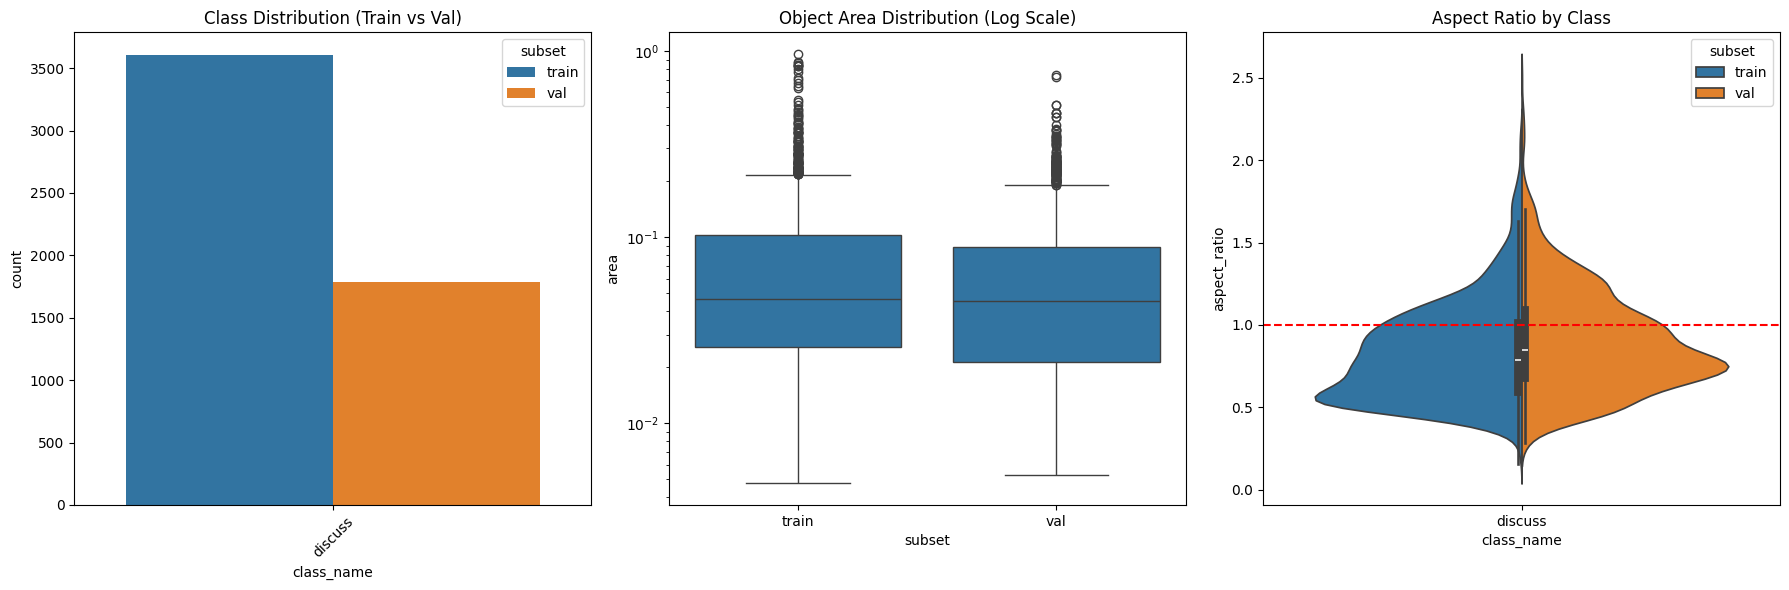

------------------------------
class_name  discuss
subset             
train          3607
val            1785
------------------------------

: SCB5-Handrise-Read-write-2024-9-17
class_name   discuss  Row_Sum
subset                       
train           3607     3607
val             1785     1785
Total_Annos     5392     5392
--------------------------------------------------
 Dataset Contains (Bounding Boxes): 5392
 Category situation:
class_name
discuss    100.0
Name: proportion, dtype: float64


In [12]:

SCB5_Discuss = "/kaggle/input/datasets/hejuncheung/scb-datasets/SCB5-Discuss-2024-9-17/SCB5-Discuss-2024-9-17"

def get_full_df(base_path):
    all_data = []
    sub_types = ['train', 'val']
    
    for stype in sub_types:
        label_files = glob.glob(os.path.join(base_path, "labels", stype, "*.txt"))
        print(f"currently processing {stype} directory {len(label_files)} find...")
        
        for lf in label_files:
            with open(lf, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        all_data.append({
                            'subset': stype,
                            'class_id': int(parts[0]),
                            'width': float(parts[3]),
                            'height': float(parts[4]),
                            'area': float(parts[3]) * float(parts[4])
                        })
    
    if not all_data:
        return pd.DataFrame()
    return pd.DataFrame(all_data)

df = get_full_df(SCB5_Discuss)

if not df.empty:
    CLASS_MAP = {0: "discuss"}
    df['class_name'] = df['class_id'].map(CLASS_MAP).fillna(df['class_id'])

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    sns.countplot(data=df, x='class_name', hue='subset')
    plt.title("Class Distribution (Train vs Val)")
    plt.xticks(rotation=45)

    plt.subplot(1, 3, 2)
    sns.boxplot(data=df, x='subset', y='area')
    plt.yscale('log') 
    plt.title("Object Area Distribution (Log Scale)")

    df['aspect_ratio'] = df['width'] / df['height']
    plt.subplot(1, 3, 3)
    sns.violinplot(data=df, x='class_name', y='aspect_ratio', hue='subset', split=True)
    plt.axhline(1, color='red', linestyle='--')
    plt.title("Aspect Ratio by Class")

    plt.tight_layout()
    plt.show()

    print("-" * 30)
    print(df.groupby(['subset', 'class_name']).size().unstack(fill_value=0))
    print("-" * 30)

    summary_df = df.groupby(['subset', 'class_name']).size().unstack(fill_value=0)
    
    summary_df.loc['Total_Annos'] = summary_df.sum()
    
    summary_df['Row_Sum'] = summary_df.sum(axis=1)

    print("\n" + "="*50)
    print(f": {os.path.basename(SCB5_Handrise_Read_write)}")
    print("="*50)
    print(summary_df)
    print("-" * 50)
    
    total_boxes = df.shape[0]
    total_imgs = df.groupby('subset').size().sum()
    print(f" Dataset Contains (Bounding Boxes): {total_boxes}")
    print(f" Category situation:\n{df['class_name'].value_counts(normalize=True) * 100}")
    print("="*50)
else:
    print("DataFrame for,please check Kaggle data path.")

 train  1905 ..
 val  505 ..


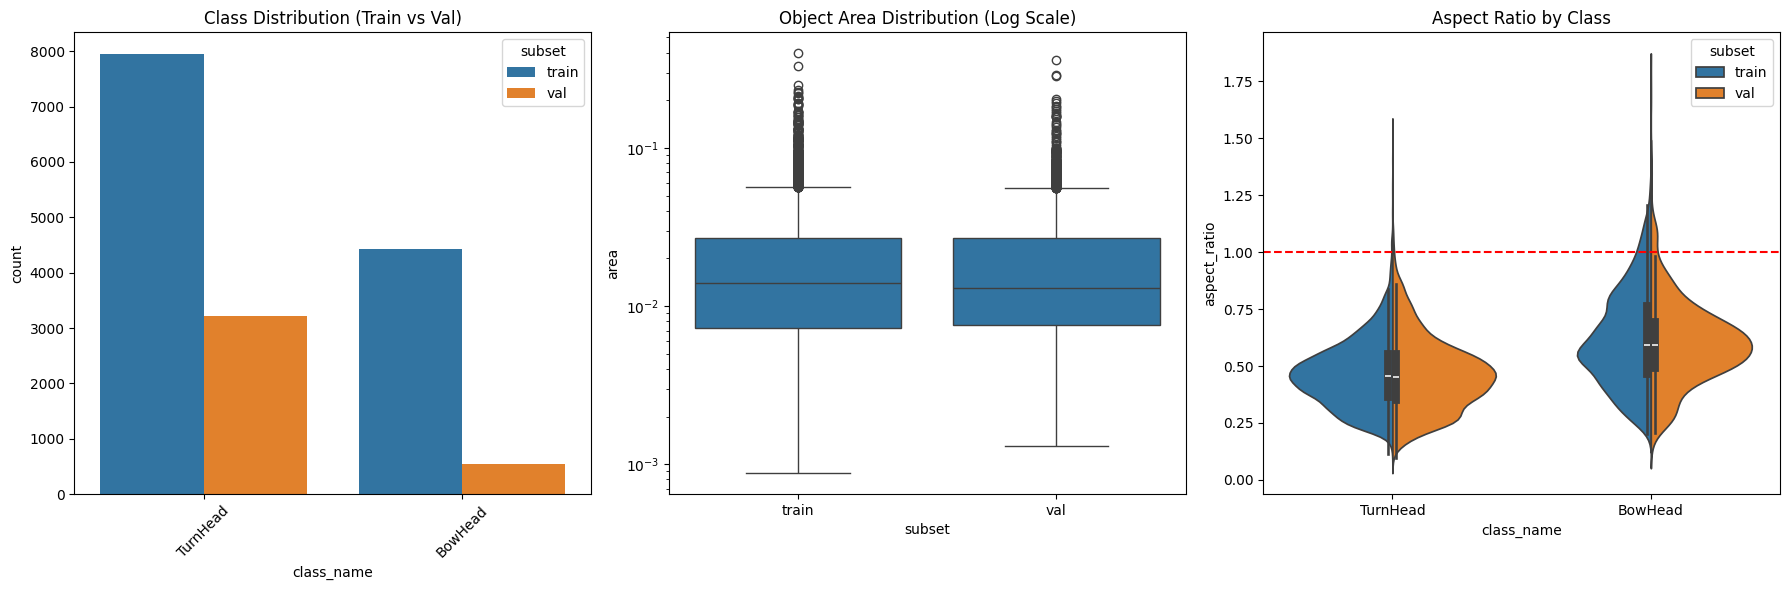

------------------------------
class_name  BowHead  TurnHead
subset                       
train          4422      7943
val             540      3213
------------------------------

: SCB5-Handrise-Read-write-2024-9-17
class_name   BowHead  TurnHead  Row_Sum
subset                                 
train           4422      7943    12365
val              540      3213     3753
Total_Annos     4962     11156    16118
--------------------------------------------------
 (Bounding Boxes): 16118 个
:
class_name
TurnHead    69.214543
BowHead     30.785457
Name: proportion, dtype: float64


In [13]:
SCB_BowTurnHead = "/kaggle/input/datasets/hejuncheung/scb-datasets/SCB_BowTurnHead_20250509/SCB_BowTurnHead_20250509/SCB5-Turn-Bow-Head-2024-9-17"

def get_full_df(base_path):
    all_data = []
    sub_types = ['train', 'val']
    
    for stype in sub_types:
        label_files = glob.glob(os.path.join(base_path, "labels", stype, "*.txt"))
        print(f" {stype}  {len(label_files)} ..")
        
        for lf in label_files:
            with open(lf, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        all_data.append({
                            'subset': stype,
                            'class_id': int(parts[0]),
                            'width': float(parts[3]),
                            'height': float(parts[4]),
                            'area': float(parts[3]) * float(parts[4])
                        })
    
    if not all_data:
        print("！！！File not found！！！")
        return pd.DataFrame()
    return pd.DataFrame(all_data)

df = get_full_df(SCB_BowTurnHead)

if not df.empty:
    CLASS_MAP = {0: "BowHead", 1: "TurnHead"}
    df['class_name'] = df['class_id'].map(CLASS_MAP).fillna(df['class_id'])

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    sns.countplot(data=df, x='class_name', hue='subset')
    plt.title("Class Distribution (Train vs Val)")
    plt.xticks(rotation=45)

    plt.subplot(1, 3, 2)
    sns.boxplot(data=df, x='subset', y='area')
    plt.yscale('log') 
    plt.title("Object Area Distribution (Log Scale)")

    df['aspect_ratio'] = df['width'] / df['height']
    plt.subplot(1, 3, 3)
    sns.violinplot(data=df, x='class_name', y='aspect_ratio', hue='subset', split=True)
    plt.axhline(1, color='red', linestyle='--')
    plt.title("Aspect Ratio by Class")

    plt.tight_layout()
    plt.show()

    print("-" * 30)
    print(df.groupby(['subset', 'class_name']).size().unstack(fill_value=0))
    print("-" * 30)

    summary_df = df.groupby(['subset', 'class_name']).size().unstack(fill_value=0)
    
    summary_df.loc['Total_Annos'] = summary_df.sum()
    
    summary_df['Row_Sum'] = summary_df.sum(axis=1)

    print("\n" + "="*50)
    print(f": {os.path.basename(SCB5_Handrise_Read_write)}")
    print("="*50)
    print(summary_df)
    print("-" * 50)
    
    total_boxes = df.shape[0]
    total_imgs = df.groupby('subset').size().sum() 
    print(f" (Bounding Boxes): {total_boxes} 个")
    print(f":\n{df['class_name'].value_counts(normalize=True) * 100}")
    print("="*50)
else:
    print("DataFrame not found on kaggle.")

train 8984 
val 3240 


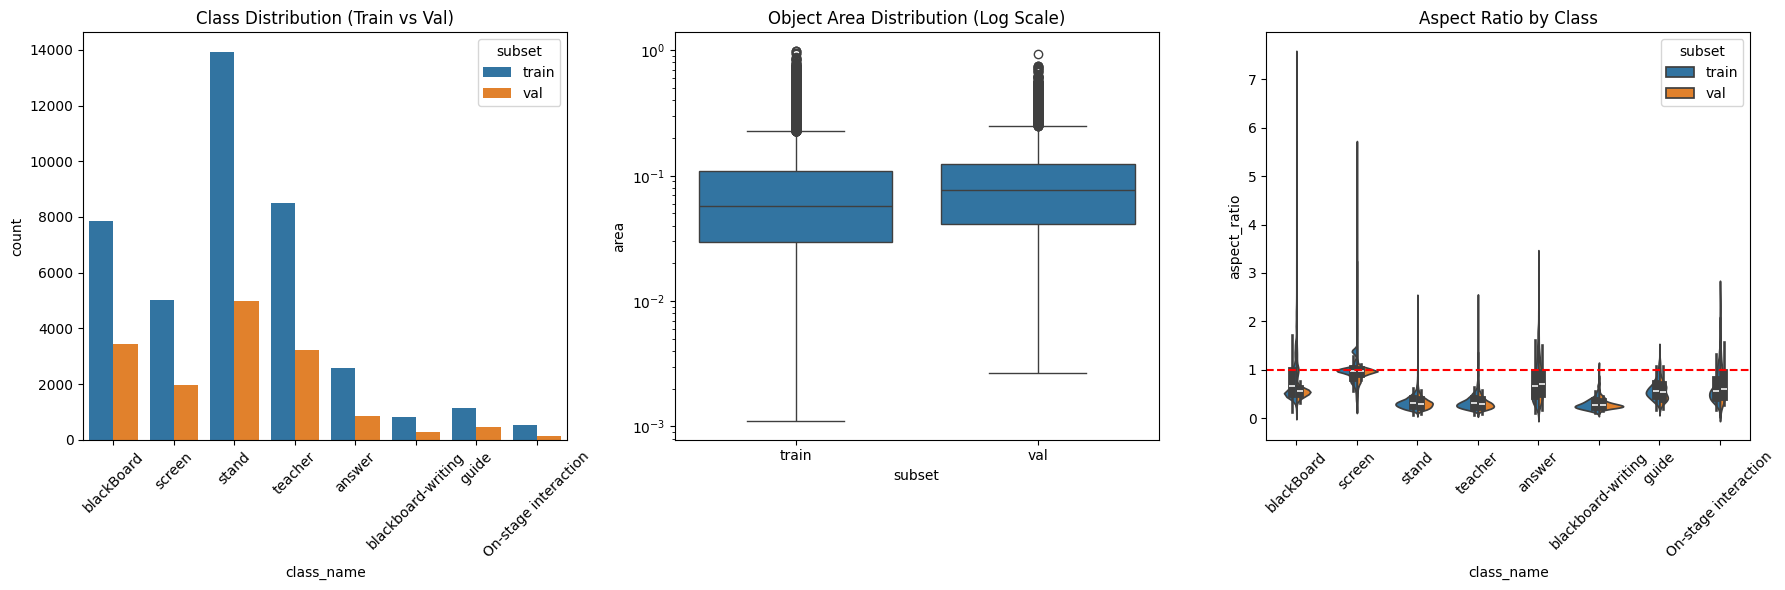

------------------------------
class_name  On-stage interaction  answer  blackBoard  blackboard-writing  \
subset                                                                     
train                        528    2574        7847                 821   
val                          149     853        3445                 277   

class_name  guide  screen  stand  teacher  
subset                                     
train        1155    5025  13932     8490  
val           449    1959   4967     3228  
------------------------------

 SCB5-Handrise-Read-write-2024-9-17
class_name   On-stage interaction  answer  blackBoard  blackboard-writing  \
subset                                                                      
train                         528    2574        7847                 821   
val                           149     853        3445                 277   
Total_Annos                   677    3427       11292                1098   

class_name   guide  screen  stand 

In [14]:
SCB5_Teacher_Behavior = "/kaggle/input/datasets/hejuncheung/scb-datasets/SCB5_Teacher_Behavior_Stand_BlackBoard_Sreen_20250406-2/SCB5_Teacher_Behavior_Stand_BlackBoard_Sreen_20250406-2"

def get_full_df(base_path):
    all_data = []
    sub_types = ['train', 'val']
    
    for stype in sub_types:
        label_files = glob.glob(os.path.join(base_path, "labels", stype, "*.txt"))
        print(f"{stype} {len(label_files)} ")
        
        for lf in label_files:
            with open(lf, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        all_data.append({
                            'subset': stype,
                            'class_id': int(parts[0]),
                            'width': float(parts[3]),
                            'height': float(parts[4]),
                            'area': float(parts[3]) * float(parts[4])
                        })
    
    if not all_data:
        print("！！！File not found！！！")
        return pd.DataFrame()
    return pd.DataFrame(all_data)

df = get_full_df(SCB5_Teacher_Behavior)

if not df.empty:
    CLASS_MAP = {0: "guide", 1: "answer", 2: "On-stage interaction", 3: "blackboard-writing", 4: "teacher", 5: "stand", 6: "screen", 7: "blackBoard"}
    df['class_name'] = df['class_id'].map(CLASS_MAP).fillna(df['class_id'])

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    sns.countplot(data=df, x='class_name', hue='subset')
    plt.title("Class Distribution (Train vs Val)")
    plt.xticks(rotation=45)

    plt.subplot(1, 3, 2)
    sns.boxplot(data=df, x='subset', y='area')
    plt.yscale('log') 
    plt.title("Object Area Distribution (Log Scale)")

    df['aspect_ratio'] = df['width'] / df['height']
    plt.subplot(1, 3, 3)
    sns.violinplot(data=df, x='class_name', y='aspect_ratio', hue='subset', split=True)
    plt.axhline(1, color='red', linestyle='--')
    plt.title("Aspect Ratio by Class")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    print("-" * 30)
    print(df.groupby(['subset', 'class_name']).size().unstack(fill_value=0))
    print("-" * 30)

    summary_df = df.groupby(['subset', 'class_name']).size().unstack(fill_value=0)
    
    summary_df.loc['Total_Annos'] = summary_df.sum()
    
    summary_df['Row_Sum'] = summary_df.sum(axis=1)

    print("\n" + "="*50)
    print(f" {os.path.basename(SCB5_Handrise_Read_write)}")
    print("="*50)
    print(summary_df)
    print("-" * 50)
    
    total_boxes = df.shape[0]
    total_imgs = df.groupby('subset').size().sum()
    print(f"(Bounding Boxes): {total_boxes} 个")
    print(f":\n{df['class_name'].value_counts(normalize=True) * 100}")
    print("="*50)
else:
    print("DataFrame not found on Kaggle ")